# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [ ]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [8]:
# !pip install tensorflow opencv-python

In [1]:
# Import essential libraries
import zipfile
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-03-08 09:46:00.300125: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-08 09:46:00.300657: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-08 09:46:00.302321: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-08 09:46:00.306461: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772963160.313189   98829 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772963160.31

Load the dataset.

In [ ]:
# Load and unzip the dataset


zip_file = "data.zip"
extract_folder = "data"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset extracted successfully!")


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [2]:
# Create a function to load the raw images
def load_images(data_path, img_size=(128,128)):
    
    images = []
    labels = []
    
    # iterate through category folders
    for category in os.listdir(data_path):
        
        category_path = os.path.join(data_path, category)
        
        if os.path.isdir(category_path):
            
            for img_name in os.listdir(category_path):
                
                img_path = os.path.join(category_path, img_name)
                
                try:
                    # read image
                    img = cv2.imread(img_path)
                    
                    # resize image
                    img = cv2.resize(img, img_size)
                    
                    # append data
                    images.append(img)
                    labels.append(category)
                
                except:
                    # skip corrupted images
                    continue
    
    return np.array(images), np.array(labels)


#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [3]:
# Get the images and their labels
data_path = "/home/utkarsh.sanwal/us/data/data"

X, y = load_images(data_path)


print("Images shape:", X.shape)
print("Labels shape:", y.shape)

print("Classes:", np.unique(y))

from collections import Counter

print(Counter(y))


Images shape: (7625, 128, 128, 3)
Labels shape: (7625,)
Classes: ['Cardboard' 'Food_Waste' 'Glass' 'Metal' 'Other' 'Paper' 'Plastic']
Counter({np.str_('Plastic'): 2295, np.str_('Paper'): 1030, np.str_('Other'): 1010, np.str_('Food_Waste'): 1000, np.str_('Metal'): 1000, np.str_('Glass'): 750, np.str_('Cardboard'): 540})


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

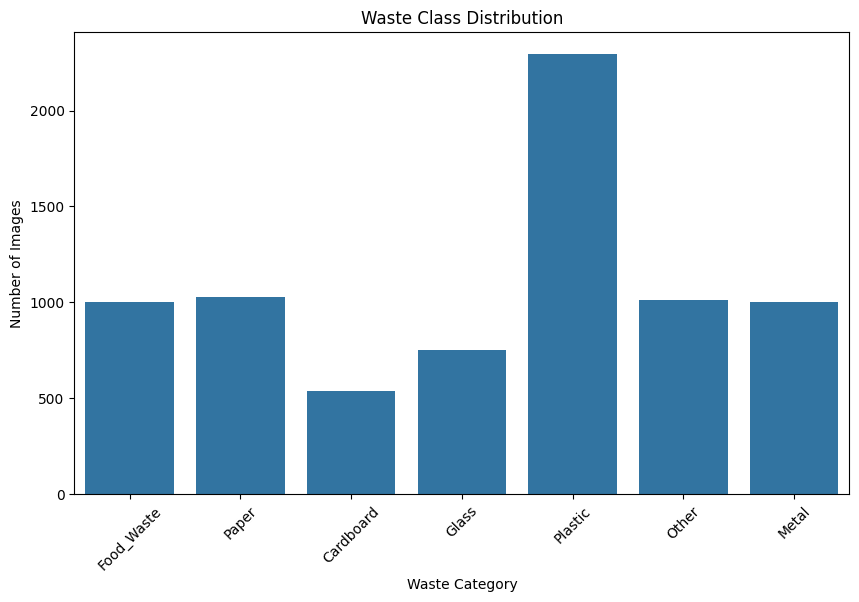

In [5]:
# Visualise Data Distribution
# Convert labels into DataFrame
df = pd.DataFrame(y, columns=["Class"])

# Plot class distribution
plt.figure(figsize=(10,6))
sns.countplot(x="Class", data=df)

plt.title("Waste Class Distribution")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()


#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

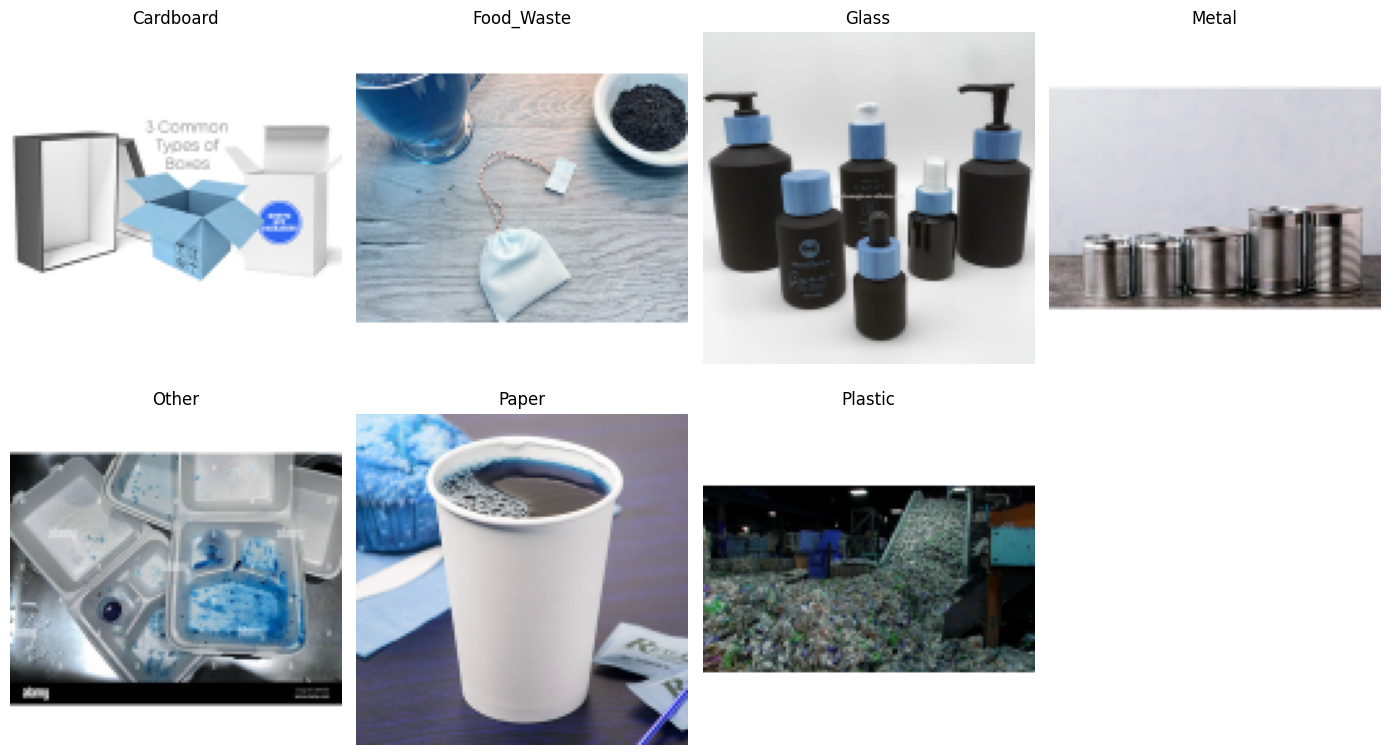

In [6]:
# Visualise Sample Images (across different labels)
classes = np.unique(y)

plt.figure(figsize=(14,8))

for i, label in enumerate(classes):
    
    # find first image index of that label
    idx = np.where(y == label)[0][0]
    
    plt.subplot(2,4,i+1)
    plt.imshow(X[idx])
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()


#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [7]:
# Find the smallest and largest image dimensions from the data set
min_height, min_width = float('inf'), float('inf')
max_height, max_width = 0, 0

for category in os.listdir(data_path):
    
    category_path = os.path.join(data_path, category)
    
    for img_name in os.listdir(category_path):
        
        img_path = os.path.join(category_path, img_name)
        
        img = cv2.imread(img_path)
        
        if img is not None:
            h, w, _ = img.shape
            
            min_height = min(min_height, h)
            min_width = min(min_width, w)
            
            max_height = max(max_height, h)
            max_width = max(max_width, w)

print("Smallest Image Dimension:", (min_height, min_width))
print("Largest Image Dimension:", (max_height, max_width))


Smallest Image Dimension: (256, 256)
Largest Image Dimension: (256, 256)


In [11]:
# Resize the image dimensions
resize_dim = (128,128)

X_resized = []

for img in X:
    
    resized_img = cv2.resize(img, resize_dim)
    
    X_resized.append(resized_img)

X_resized = np.array(X_resized)
X_resized = X_resized / 255.0
print("Resized image shape:", X_resized.shape)


Resized image shape: (7625, 128, 128, 3)


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [13]:
# Encode the labels suitably

label_encoder = LabelEncoder()

# Convert text labels to numeric labels
y_encoded = label_encoder.fit_transform(y)

# Convert numeric labels to one-hot encoded format
y_encoded = to_categorical(y_encoded)


print("Encoded labels shape:", y_encoded.shape)


Encoded labels shape: (7625, 7)


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [14]:
# Assign specified parts of the dataset to train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_resized,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Images:", X_train.shape)
print("Validation Images:", X_val.shape)

print("Training Labels:", y_train.shape)
print("Validation Labels:", y_val.shape)
print(X_train.min(), X_train.max())

Training Images: (6100, 128, 128, 3)
Validation Images: (1525, 128, 128, 3)
Training Labels: (6100, 7)
Validation Labels: (1525, 7)
0.0 1.0


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [31]:
tf.keras.backend.clear_session()

In [32]:
# Build and compile the model
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

model = tf.keras.Sequential([
    
  tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Dropout(0.2),

  tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.MaxPooling2D(2,2),
  tf.keras.layers.Dropout(0.2),

  tf.keras.layers.Flatten(),

  tf.keras.layers.Dense(128,activation='relu'),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Dropout(0.4),

  tf.keras.layers.Dense(7,activation='softmax')
])
# View model architecture
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 124, 124, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 58, 58, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 53824)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,889,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,957,351 (26.54 MB)

 Trainable params: 6,956,711 (26.54 MB)

 Non-trainable params: 640 (2.50 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [33]:
from tensorflow import keras
model.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)


In [35]:
# Training
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

y_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)

class_weights = dict(enumerate(class_weights))


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True
)

# Train the model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 41s 215ms/step - accuracy: 0.3239 - loss: 2.0259 - val_accuracy: 0.1534 - val_loss: 2.5531
Epoch 2/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 41s 214ms/step - accuracy: 0.5021 - loss: 1.4416 - val_accuracy: 0.3548 - val_loss: 1.7272
Epoch 3/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 41s 215ms/step - accuracy: 0.6172 - loss: 1.1175 - val_accuracy: 0.5082 - val_loss: 1.4562
Epoch 4/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 41s 214ms/step - accuracy: 0.7144 - loss: 0.8486 - val_accuracy: 0.5711 - val_loss: 1.3927
Epoch 5/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 41s 214ms/step - accuracy: 0.7785 - loss: 0.6740 - val_accuracy: 0.4905 - val_loss: 3.6766
Epoch 6/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 41s 215ms/step - accuracy: 0.8415 - loss: 0.5238 - val_accuracy: 0.5915 - val_loss: 1.6927
Epoch 7/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 41s 215ms/step - accuracy: 0.8760 - loss: 0.4310 - val_accuracy: 0.5659 - val_loss: 1.6177
Epoch 8/50
191/191 ━━━━━━━━━━━━━━━━━━━━ 41s 214ms/step - accuracy: 0.8933 - loss: 0

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.

In [36]:
# Evaluate on the test set; display suitable metrics

# Evaluate accuracy and loss
loss, accuracy = model.evaluate(X_val, y_val)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

# Predictions
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.6267 - loss: 2.0092
Test Loss: 2.1051392555236816
Test Accuracy: 0.6072131395339966
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.84      0.76       108
           1       0.57      0.61      0.59       200
           2       0.69      0.44      0.54       150
           3       0.58      0.71      0.64       200
           4       0.48      0.51      0.49       202
           5       0.45      0.68      0.54       206
           6       0.84      0.57      0.68       459

    accuracy                           0.61      1525
   macro avg       0.61      0.62      0.61      1525
weighted avg       0.64      0.61      0.61      1525


Confusion Matrix:
[[ 91   2   0   3   1  11   0]
 [ 13 123   4  13  13  26   8]
 [  8  11  66  18  20  16  11]
 [  1  11   5 143   9  21  10]
 [  5  20   3  19 103  39  13]
 [  5  16   5  13  18 140  

## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [37]:
# Define augmentation steps to augment images
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [38]:
# Create a function to augment the images

def augment_images(X_train, y_train, datagen, batch_size=32):
    
    datagen.fit(X_train)
    
    augmented_data = datagen.flow(
        X_train,
        y_train,
        batch_size=batch_size
    )
    
    return augmented_data


In [39]:
# Create the augmented training dataset
batch_size = 32

augmented_train_data = augment_images(
    X_train,
    y_train,
    datagen,
    batch_size
)


##### **4.1.2**

Train the model on the new augmented dataset.

In [40]:
# Train the model using augmented images

history_aug = model.fit(
    augmented_train_data,
    steps_per_epoch=len(X_train) // batch_size,
    epochs=20,
    validation_data=(X_val, y_val)
)

Epoch 1/20


/home/utkarsh.sanwal/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


190/190 ━━━━━━━━━━━━━━━━━━━━ 42s 218ms/step - accuracy: 0.3911 - loss: 2.5290 - val_accuracy: 0.4492 - val_loss: 3.0120
Epoch 2/20
  1/190 ━━━━━━━━━━━━━━━━━━━━ 38s 205ms/step - accuracy: 0.4062 - loss: 2.2795

/home/utkarsh.sanwal/anaconda3/envs/ml_env/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4062 - loss: 2.2795 - val_accuracy: 0.4439 - val_loss: 3.0178
Epoch 3/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 41s 217ms/step - accuracy: 0.4090 - loss: 1.9228 - val_accuracy: 0.3875 - val_loss: 3.0636
Epoch 4/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4375 - loss: 1.6378 - val_accuracy: 0.3849 - val_loss: 2.9815
Epoch 5/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 41s 217ms/step - accuracy: 0.4335 - loss: 1.8095 - val_accuracy: 0.5095 - val_loss: 1.7666
Epoch 6/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6562 - loss: 1.5322 - val_accuracy: 0.5075 - val_loss: 1.7681
Epoch 7/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 41s 217ms/step - accuracy: 0.4362 - loss: 1.7523 - val_accuracy: 0.5370 - val_loss: 1.5686
Epoch 8/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3125 - loss: 2.1354 - val_accuracy: 0.5357 - val_loss: 1.5642
Epoch 9/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 41s 217ms/step - accuracy: 0.4618 - loss: 1.6892 - val_accuracy: 0

## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results


#### Dataset Findings
The dataset consists of **7,625** images belonging to seven waste categories: Cardboard, Food Waste, Glass,
Metal, Other, Paper and Plastic. The images were originally 256x256 in size and were resized to **128x128**
to reduce computational cost during training. The dataset is imbalanced, with Plastic having the largest
number of samples **(2295)** and Cardboard having the fewest **(540)**. This imbalance can influence the model
to favor classes with more samples.

#### Model Training Results (Without Augmentation)
A Convolutional Neural Network (CNN) with multiple convolutional, batch normalization, dropout and dense
layers was trained on the dataset. The model achieved a very high training accuracy **(~98%)** but a validation
accuracy of around **60%**. This indicates overfitting, where the model memorizes training data but struggles
to generalize well to unseen images.

#### Model Training Results (With Data Augmentation)
Data augmentation techniques such as rotation, shifting, zooming and horizontal flipping were applied to
increase the diversity of the training dataset. After augmentation, the training accuracy decreased to
around **59%** and validation accuracy was approximately **50%**. Although augmentation reduced overfitting by
making the task harder for the model, the validation performance did not significantly improve, suggesting
that the model architecture or dataset size may still limit performance.

#### Insights
Overall, **the CNN model was able to learn meaningful patterns from the waste images**, achieving significantly
better performance than random guessing **(≈14% for seven classes)**. However, class imbalance and the limited
dataset size affected generalization performance. Future improvements could include collecting more data,
using stronger regularization, or applying transfer learning with pre-trained models such as ResNet or
MobileNet to achieve better classification accuracy.